In [1]:
!pip install imbalanced-learn wordcloud xgboost --quiet

# Import all libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import string
import kagglehub
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import joblib
import os
import json
from scipy.sparse import csr_matrix
from scipy.sparse import hstack
import warnings
warnings.filterwarnings('ignore')

# Load the dataset

In [41]:
!pip install -q kagglehub pandas

dataset_path = kagglehub.dataset_download(
    "shivamb/real-or-fake-fake-jobposting-prediction"
)

print("Dataset downloaded at:")
print(dataset_path)

files = os.listdir(dataset_path)
print("\nFiles found:")
print(files)

csv_file = None

for file in files:
    if file.endswith(".csv"):
        csv_file = file
        break

if csv_file is None:
    raise Exception("No CSV file found!")

df = pd.read_csv(os.path.join(dataset_path, csv_file))

print("\nDataset Loaded Successfully!")


Using Colab cache for faster access to the 'real-or-fake-fake-jobposting-prediction' dataset.
Dataset downloaded at:
/kaggle/input/real-or-fake-fake-jobposting-prediction

Files found:
['fake_job_postings.csv']

Dataset Loaded Successfully!


# EDA

In [42]:
print(f'Total rows (job postings): {df.shape[0]:,}')
print(f'Total columns (features):  {df.shape[1]}')

Total rows (job postings): 17,880
Total columns (features):  18


In [43]:
print('COLUMNS IN DATASET:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

COLUMNS IN DATASET:
   1. job_id
   2. title
   3. location
   4. department
   5. salary_range
   6. company_profile
   7. description
   8. requirements
   9. benefits
  10. telecommuting
  11. has_company_logo
  12. has_questions
  13. employment_type
  14. required_experience
  15. required_education
  16. industry
  17. function
  18. fraudulent


In [44]:
display(df.head(3))

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


In [45]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [46]:
print('TARGET COLUMN (fraudulent):')
print(df['fraudulent'].value_counts())
(df['fraudulent'].value_counts(normalize=True)*100)

print('This is called CLASS IMBALANCE as small portion is fake data')

TARGET COLUMN (fraudulent):
fraudulent
0    17014
1      866
Name: count, dtype: int64
This is called CLASS IMBALANCE as small portion is fake data


In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.isnull().sum().sort_values(ascending=False)

,0
salary_range,15012
department,11547
required_education,8105
benefits,7212
required_experience,7050
function,6455
industry,4903
employment_type,3471
company_profile,3308
requirements,2696


# Chart 1: Class Distribution (Fake vs Real)

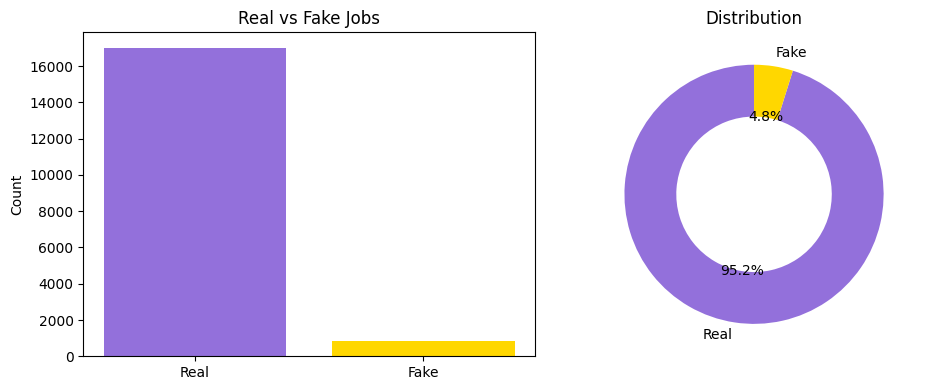

In [49]:
import matplotlib.pyplot as plt

counts = df['fraudulent'].value_counts()
colors = ['mediumpurple', 'gold']

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Bar Chart
ax[0].bar(['Real', 'Fake'], counts.values, color=colors)
ax[0].set_title('Real vs Fake Jobs')
ax[0].set_ylabel('Count')

# Donut Chart
ax[1].pie(counts.values,
          labels=['Real', 'Fake'],
          colors=colors,
          autopct='%1.1f%%',
          startangle=90,
          wedgeprops={'width':0.4})

ax[1].set_title('Distribution')

plt.tight_layout()
plt.show()

# Chart 2: Missing Values Heatmap

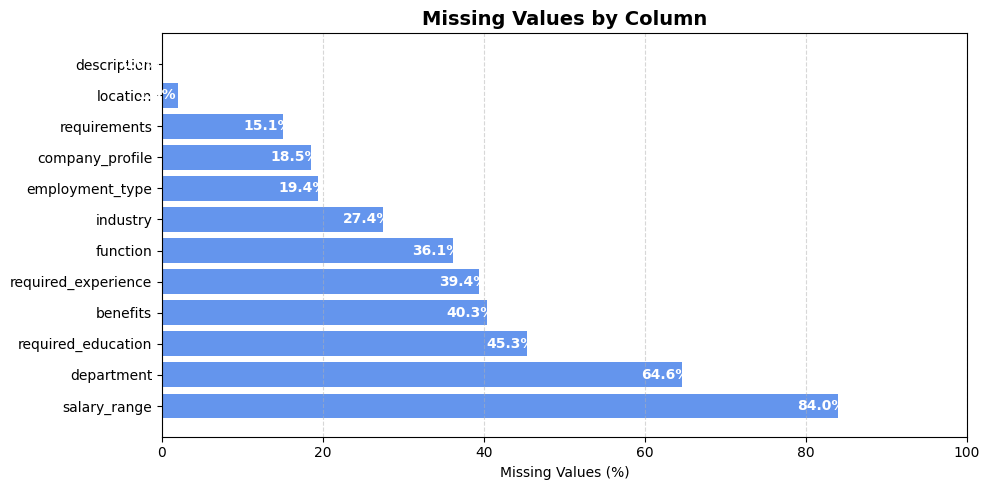

In [50]:
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df = missing_percent[missing_percent > 0].reset_index()
missing_df.columns = ['Column', 'Missing %']

plt.figure(figsize=(10, 5))

bars = plt.barh(
    missing_df['Column'],
    missing_df['Missing %'],
    color='cornflowerblue'
)

plt.xlabel('Missing Values (%)')
plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add labels inside bars
for bar, val in zip(bars, missing_df['Missing %']):
    plt.text(val - 5,
             bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%',
             va='center',
             color='white',
             fontweight='bold')

plt.tight_layout()
plt.show()

# Chart 3: Top 10 Industries with Fake Jobs

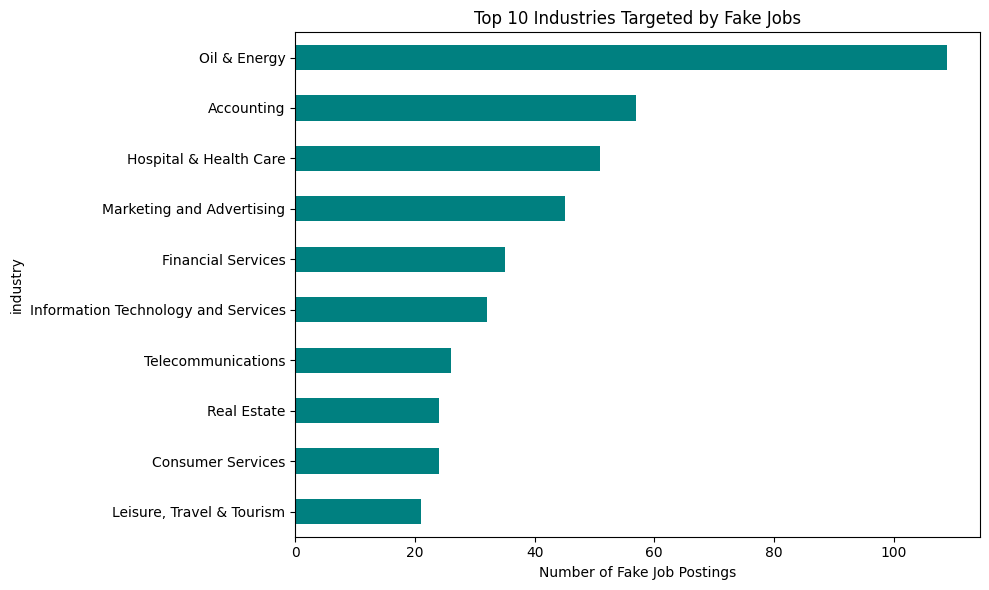

In [51]:
fake_jobs = df[df['fraudulent'] == 1]
fake_industry = fake_jobs['industry'].dropna().value_counts().head(10)

plt.figure(figsize=(10, 6))
fake_industry.plot(kind='barh', color='teal')
plt.title('Top 10 Industries Targeted by Fake Jobs')
plt.xlabel('Number of Fake Job Postings')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Chart 4: Word Clouds for Fake vs Real Jobs

In [52]:
# Separate fake and real jobs
fake_jobs = df[df['fraudulent'] == 1]
real_jobs = df[df['fraudulent'] == 0]

# Combine title and description into one text string
fake_text = ' '.join(
    (fake_jobs['title'].fillna('') + ' ' +
     fake_jobs['description'].fillna('')).tolist()
)

real_text = ' '.join(
    (real_jobs['title'].fillna('') + ' ' +
     real_jobs['description'].fillna('')).tolist()
)

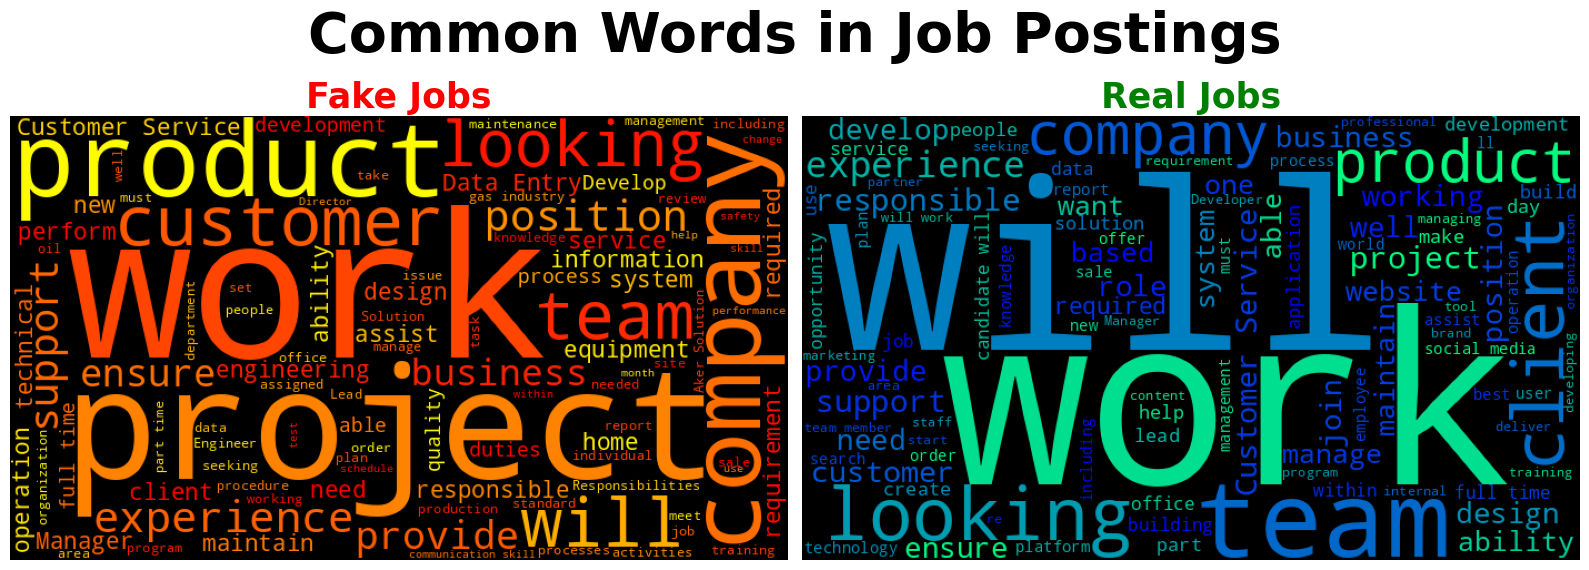

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Fake jobs word cloud
wc_fake = WordCloud(
    width=700, height=400,
    background_color='black',
    colormap='autumn',
    max_words=100
).generate(fake_text)

axes[0].imshow(wc_fake)
axes[0].axis('off')
axes[0].set_title('Fake Jobs', fontsize=25, color='red', fontweight='bold')

# Real jobs word cloud
wc_real = WordCloud(
    width=700, height=400,
    background_color='black',
    colormap='winter',
    max_words=100
).generate(real_text)

axes[1].imshow(wc_real)
axes[1].axis('off')
axes[1].set_title('Real Jobs', fontsize=25, color='green', fontweight='bold')

# Main title
plt.suptitle('Common Words in Job Postings', fontsize=40, fontweight='bold', y=0.92)

plt.tight_layout()
plt.show()

In [54]:
# Observation: The vocabulary used in fake and real job postings is largely similar, indicating that simple keyword-based
#              approaches are insufficient and highlighting the importance of using TF-IDF along with machine learning models.

# Data Preprocessing and Feature Engineering

In [55]:
df.drop(
    columns=[
        'job_id',
        'salary_range',
        'department'
    ],
    inplace=True
)

In [56]:
text_cols = [
    'company_profile',
    'description',
    'requirements',
    'benefits',
    'employment_type',
    'required_experience',
    'required_education',
    'industry',
    'function',
    'location'
]

for col in text_cols:
    df[col] = df[col].fillna('')

In [57]:
df.isnull().sum()

,0
title,0
location,0
company_profile,0
description,0
requirements,0
benefits,0
telecommuting,0
has_company_logo,0
has_questions,0
employment_type,0


In [58]:
df.shape

(17880, 15)

In [59]:
#CREATE COMBINED TEXT
df['combined_text'] = (
    df['title'] + ' ' +
    df['company_profile'] + ' ' +
    df['description'] + ' ' +
    df['requirements'] + ' ' +
    df['benefits']
)

In [60]:
df['combined_text'].head(1)

,combined_text
0,"Marketing Intern We're Food52, and we've creat..."


In [61]:
df['combined_text'].str.len().describe()

,combined_text
count,17880.000000
mean,2670.464094
std,1465.514148
min,18.000000
25%,1595.000000
50%,2522.000000
75%,3475.000000
max,14945.000000


# Text Cleaning

In [109]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()
    text = re.sub(r'\S+@\S+', ' email_token ', text)
    text = re.sub(r'\d+', ' number_token ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [64]:
df['clean_text'] = df['combined_text'].apply(clean_text)

In [65]:
print(df['clean_text'][0][:1000])

marketing intern food number token created groundbreaking award winning cooking site support connect celebrate home cook give everything need one place top editorial business engineering team focused using technology find new better way connect people around specific food interest offer superb highly curated information food cooking attract talented home cook contributor country also publish well known professional like mario batali gwyneth paltrow danny meyer partnership whole food market random house food number token named best food website james beard foundation iacp featured new york time npr pando daily techcrunch today show located chelsea new york city food number token fast growing james beard award winning online food community crowd sourced curated recipe hub currently interviewing full part time unpaid intern work small team editor executive developer new york city headquarters reproducing repackaging existing food number token content number partner site huffington post ya

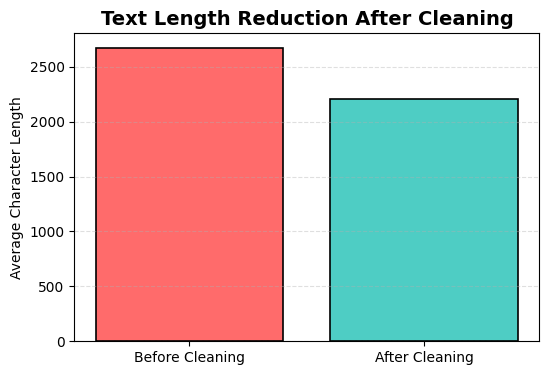

In [66]:
df['before_len'] = df['combined_text'].astype(str).apply(len)
df['after_len'] = df['clean_text'].astype(str).apply(len)

avg_before = df['before_len'].mean()
avg_after = df['after_len'].mean()

plt.figure(figsize=(6,4))

plt.bar(
    ['Before Cleaning', 'After Cleaning'],
    [avg_before, avg_after],
    color=['#FF6B6B', '#4ECDC4'],
    edgecolor='black',
    linewidth=1.2
)

plt.title('Text Length Reduction After Cleaning', fontsize=14, fontweight='bold')
plt.ylabel('Average Character Length')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# Adding Extra Features, Feature Engineering

In [67]:
df['text_length'] = df['clean_text'].astype(str).apply(len)

df['word_count'] = df['clean_text'].astype(str).apply(lambda x: len(x.split()))

df['has_company_logo'] = df['has_company_logo'].fillna(0).astype(int)

df['telecommuting'] = df['telecommuting'].fillna(0).astype(int)

df['has_questions'] = df['has_questions'].fillna(0).astype(int)

df['has_salary'] = df['clean_text'].str.contains('salary|pay|compensation', case=False, na=False).astype(int)

df['has_urgent'] = df['clean_text'].str.contains('urgent|immediately|hurry|quickly', case=False, na=False).astype(int)

df['has_remote'] = df['clean_text'].str.contains('remote|work from home|wfh', case=False, na=False).astype(int)

df['has_email'] = (df['combined_text'].str.contains(r'\S+@\S+', na=False).astype(int))

df['is_short_desc'] = (df['word_count'] < 50).astype(int)

df['is_long_desc'] = (df['word_count'] > 500).astype(int)

In [68]:
extra_features = ['text_length', 'word_count', 'has_company_logo', 'telecommuting', 'has_questions','has_salary','has_urgent',
                  'has_remote','has_email','is_short_desc','is_long_desc']
df[extra_features + ['fraudulent']].describe().round(2)

,text_length,word_count,has_company_logo,telecommuting,has_questions,has_salary,has_urgent,has_remote,has_email,is_short_desc,is_long_desc,fraudulent
count,17880.00,17880.00,17880.0,17880.00,17880.00,17880.00,17880.00,17880.00,17880.00,17880.00,17880.00,17880.00
mean,2205.74,287.31,0.8,0.04,0.49,0.40,0.15,0.04,0.01,0.01,0.09,0.05
std,1186.22,155.51,0.4,0.20,0.50,0.49,0.36,0.21,0.09,0.12,0.29,0.21
min,14.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1320.00,174.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,2047.00,259.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,2843.00,370.00,1.0,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
max,12259.00,1531.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


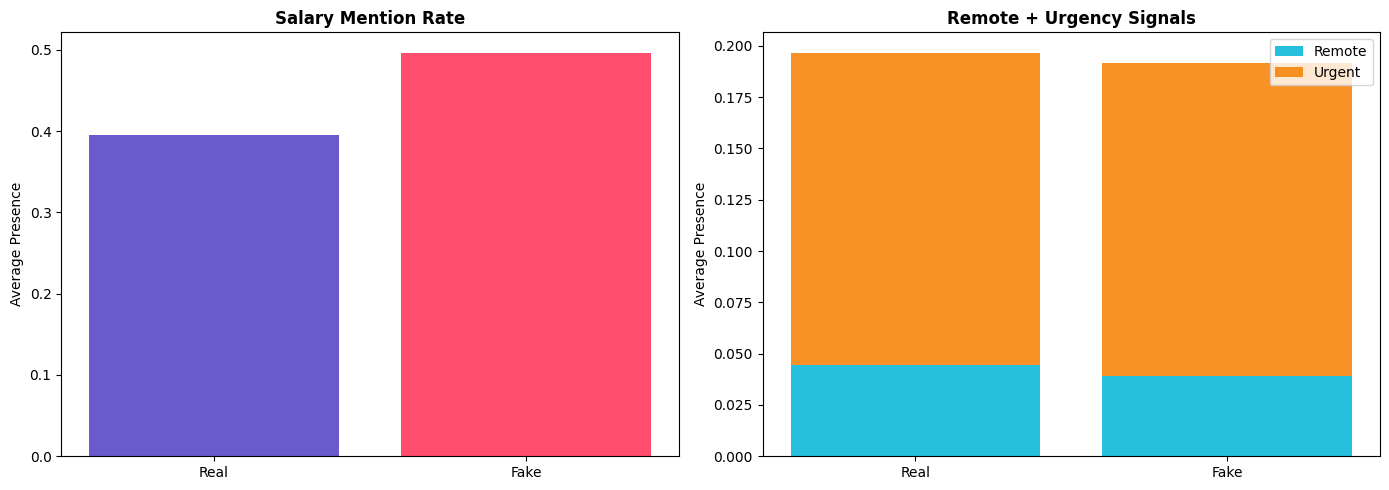

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

salary_rate = df.groupby('fraudulent')['has_salary'].mean()

axes[0].bar(
    ['Real', 'Fake'],
    salary_rate.values,
    color=['#6A5ACD', '#FF4D6D']
)

axes[0].set_title('Salary Mention Rate', fontweight='bold')
axes[0].set_ylabel('Average Presence')

remote_rate = df.groupby('fraudulent')['has_remote'].mean()
urgent_rate = df.groupby('fraudulent')['has_urgent'].mean()

x = ['Real', 'Fake']

axes[1].bar(x, remote_rate.values, color='#00B4D8', alpha=0.85, label='Remote')
axes[1].bar(x, urgent_rate.values, bottom=remote_rate.values,
            color='#F77F00', alpha=0.85, label='Urgent')

axes[1].set_title('Remote + Urgency Signals', fontweight='bold')
axes[1].set_ylabel('Average Presence')
axes[1].legend()

plt.tight_layout()
plt.show()

In [70]:
#Observation: Fake job postings show lower salary mention rates but higher presence of urgency-related terms and remote-work
#             claims, indicating deceptive intent and spam-like recruitment behavior.

In [71]:
y = df['fraudulent'].values

# Train-Test Split

In [72]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF Vectorization

In [73]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_tfidf_train = tfidf.fit_transform(X_train_text)
X_tfidf_test = tfidf.transform(X_test_text)

In [74]:
feature_cols = [
    'text_length', 'word_count', 'has_company_logo', 'telecommuting', 'has_questions','has_salary','has_urgent',
                  'has_remote','has_email','is_short_desc','is_long_desc'
]

X_train_extra = df.loc[X_train_text.index, feature_cols]
X_test_extra = df.loc[X_test_text.index, feature_cols]

In [75]:
#Convert to sparse + combine
X_train_final = hstack([X_tfidf_train, csr_matrix(X_train_extra.values)])
X_test_final  = hstack([X_tfidf_test, csr_matrix(X_test_extra.values)])

In [76]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print("Real:", (y_train == 0).sum())
print("Fake:", (y_train == 1).sum())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train)

print("\nAfter SMOTE:")
print("Real:", (y_train_smote == 0).sum())
print("Fake:", (y_train_smote == 1).sum())

print("\n✔ Class imbalance handled using SMOTE (Synthetic Minority Oversampling Technique)")

Before SMOTE:
Real: 13611
Fake: 693

After SMOTE:
Real: 13611
Fake: 13611

✔ Class imbalance handled using SMOTE (Synthetic Minority Oversampling Technique)


# Train three models and compare

In [77]:
def train_evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    print(f'Training {model_name}...', end=' ')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results = {
        'model': model,
        'name': model_name,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, y_proba),
        'y_pred':    y_pred,
        'y_proba':   y_proba
    }

    print(f'Done! F1={results["f1"]:.3f}, ROC-AUC={results["roc_auc"]:.3f}')
    return results

# Model 1: Logistic Regression

In [81]:

# The simplest model. Good baseline.
# max_iter=1000 → increase iterations so it converges properly
# C=1.0 → regularization strength (prevents overfitting)
# class_weight='balanced' → another way to handle imbalance

lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    random_state=42
)
lr_results = train_evaluate_model(
    lr_model, 'Logistic Regression',
    X_train_smote, y_train_smote,  # use SMOTE balanced data
    X_test_final, y_test            # test on original distribution
)

Training Logistic Regression... Done! F1=0.678, ROC-AUC=0.984


# Model 2: Random Forest

In [82]:

# An ensemble of decision trees
# n_estimators=100 → build 100 trees and take a vote
# max_depth=20 → limit tree depth to prevent overfitting
# n_jobs=-1 → use all CPU cores for speed

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_results = train_evaluate_model(
    rf_model, 'Random Forest',
    X_train_smote, y_train_smote,
    X_test_final, y_test
)


Training Random Forest... Done! F1=0.793, ROC-AUC=0.990


# Model 3: XG Boost

In [91]:
#Gradient Boosting: builds trees sequentially, each correcting previous errors
# scale_pos_weight = ratio of negative/positive = handles imbalance
# use_label_encoder=False, eval_metric='logloss' → suppress warnings

# Calculate scale_pos_weight
from sklearn.model_selection import RandomizedSearchCV

# 1. Class ratio (use original data, not SMOTE)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f'scale_pos_weight = {scale:.1f}')

# 2. Hyperparameter search space
param_grid = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 1.0],      # row sampling → reduces overfit
    'colsample_bytree': [0.7, 0.8, 1.0],      # feature sampling → reduces overfit
    'min_child_weight': [1, 3, 5],             # min samples per leaf
}

# 3. Base model
xgb_base = XGBClassifier(
    scale_pos_weight=scale,   # handles imbalance natively
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

# 4. RandomizedSearch (faster than GridSearch)
search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=10,              # tries 20 random combos
    scoring='f1',           # optimize for F1 (balances precision + recall)
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train on ORIGINAL data (scale_pos_weight already handles imbalance)
search.fit(X_train_final, y_train)    # ← NOT X_train_smote

print(f'\nBest params: {search.best_params_}')
print(f'Best CV F1:  {search.best_score_:.4f}')

# 5. Best model
best_xgb = search.best_estimator_

# 6. Threshold tuning (key improvement!)
y_proba = best_xgb.predict_proba(X_test_final)[:, 1]

print('\n── Threshold Comparison ──')
for thresh in [0.3, 0.4, 0.5]:
    y_pred = (y_proba >= thresh).astype(int)
    report = classification_report(y_test, y_pred, output_dict=True)
    print(f'Threshold {thresh} → '
          f'Recall: {report["1"]["recall"]:.4f} | '
          f'Precision: {report["1"]["precision"]:.4f} | '
          f'F1: {report["1"]["f1-score"]:.4f}')

# 7. Final prediction (choose best threshold from above)
BEST_THRESHOLD = 0.4    # adjust after seeing results above

y_final = (y_proba >= BEST_THRESHOLD).astype(int)
print(f'\n── Final Report (threshold={BEST_THRESHOLD}) ──')
print(classification_report(y_test, y_final))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_final))

scale_pos_weight = 19.6
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best params: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV F1:  0.7809

── Threshold Comparison ──
Threshold 0.3 → Recall: 0.8728 | Precision: 0.7295 | F1: 0.7947
Threshold 0.4 → Recall: 0.8555 | Precision: 0.8000 | F1: 0.8268
Threshold 0.5 → Recall: 0.8382 | Precision: 0.8529 | F1: 0.8455

── Final Report (threshold=0.4) ──
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.80      0.86      0.83       173

    accuracy                           0.98      3576
   macro avg       0.90      0.92      0.91      3576
weighted avg       0.98      0.98      0.98      3576

Confusion Matrix:
[[3366   37]
 [  25  148]]


# Compare Models and select the best one

In [92]:
all_results = [lr_results, rf_results, xgb_results]

comparison_df = pd.DataFrame([
    {
        'Model': r['name'],
        'Accuracy': f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'F1 Score': f"{r['f1']:.4f}",
        'ROC-AUC': f"{r['roc_auc']:.4f}"
    }
    for r in all_results
])

print('=' * 70)
print('MODEL COMPARISON TABLE')
print('=' * 70)
print(comparison_df.to_string(index=False))
print()
print('KEY: For fraud detection, F1 Score and Recall matter most!')
print('Recall = how many fake jobs we actually catch')

MODEL COMPARISON TABLE
              Model Accuracy Precision Recall F1 Score ROC-AUC
Logistic Regression   0.9595    0.5504 0.8844   0.6785  0.9842
      Random Forest   0.9832    0.9829 0.6647   0.7931  0.9900
            XGBoost   0.9762    0.7178 0.8382   0.7733  0.9864

KEY: For fraud detection, F1 Score and Recall matter most!
Recall = how many fake jobs we actually catch


# Visualize the comparison of models

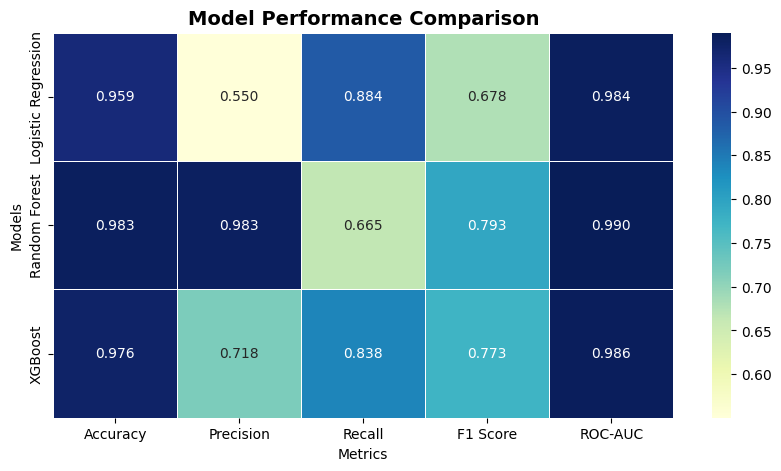

In [93]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

# Create dataframe for heatmap
data = []

for r in all_results:
    data.append([r[m] for m in metrics])

df_cm = pd.DataFrame(data, columns=metric_labels)
df_cm.index = [r['name'] for r in all_results]

plt.figure(figsize=(10, 5))

sns.heatmap(
    df_cm,
    annot=True,
    cmap='YlGnBu',
    linewidths=0.5,
    fmt='.3f'
)

plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Models')
plt.xlabel('Metrics')

plt.show()

# ROC Curve Plot

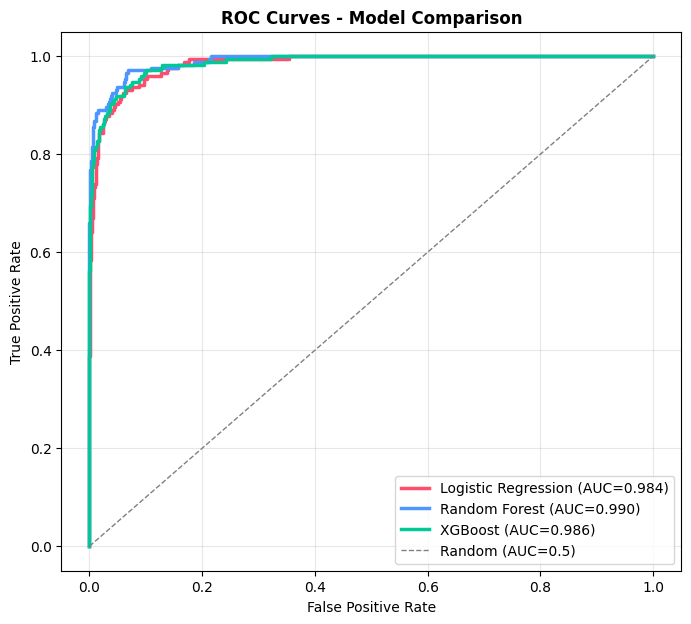

In [94]:
plt.figure(figsize=(8, 7))
colors_list = ['#FF4D6D', '#4D96FF', '#00C896']

for results, color in zip(all_results, colors_list):
    fpr, tpr, _ = roc_curve(y_test, results['y_proba'])
    auc = results['roc_auc']

    plt.plot(
        fpr, tpr,
        color=color,
        label=f"{results['name']} (AUC={auc:.3f})",
        linewidth=2.5
    )

# Random baseline
plt.plot([0,1], [0,1], 'gray', linestyle='--', linewidth=1, label='Random (AUC=0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison', fontweight='bold')

plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.show()

In [97]:
print("=" * 60)
print("MODEL SELECTION SUMMARY")
print("=" * 60)

best_recall = max(all_results, key=lambda x: x['recall'])
best_f1 = max(all_results, key=lambda x: x['f1'])

print(f"Highest Recall : {best_recall['name']} ({best_recall['recall']:.4f})")
print(f"Highest F1     : {best_f1['name']} ({best_f1['f1']:.4f})")

# Final chosen model
best_result = next(
    x for x in all_results
    if x['name'] == 'XGBoost'
)

best_model = best_result['model']

print("\n" + "=" * 60)
print("FINAL DEPLOYED MODEL: XGBoost")
print("=" * 60)

print(f"Accuracy  : {best_result['accuracy']:.4f}")
print(f"Precision : {best_result['precision']:.4f}")
print(f"Recall    : {best_result['recall']:.4f}")
print(f"F1 Score  : {best_result['f1']:.4f}")
print(f"ROC-AUC   : {best_result['roc_auc']:.4f}")

print("\nReason:")
print("XGBoost provides the best balance between")
print("Recall, Precision, F1 Score, and ROC-AUC,")
print("making it the most suitable model for deployment.")

MODEL SELECTION SUMMARY
Highest Recall : Logistic Regression (0.8844)
Highest F1     : Random Forest (0.7931)

FINAL DEPLOYED MODEL: XGBoost
Accuracy  : 0.9762
Precision : 0.7178
Recall    : 0.8382
F1 Score  : 0.7733
ROC-AUC   : 0.9864

Reason:
XGBoost provides the best balance between
Recall, Precision, F1 Score, and ROC-AUC,
making it the most suitable model for deployment.


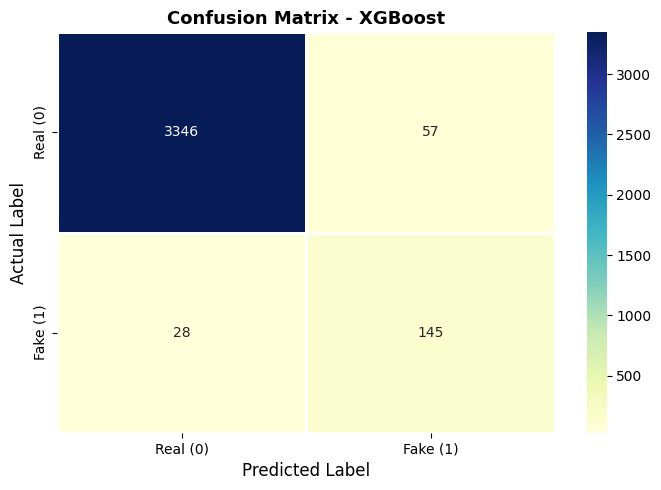


DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Real Job       0.99      0.98      0.99      3403
    Fake Job       0.72      0.84      0.77       173

    accuracy                           0.98      3576
   macro avg       0.85      0.91      0.88      3576
weighted avg       0.98      0.98      0.98      3576



In [98]:
#CONFUSION MATRIX FOR BEST MODEL

# Confusion matrix shows:
# True Positive (TP): Fake job → predicted Fake ✓
# True Negative (TN): Real job → predicted Real ✓
# False Positive (FP): Real job → predicted Fake ✗ (false alarm)
# False Negative (FN): Fake job → predicted Real ✗ (missed fraud!)

cm = confusion_matrix(y_test, best_result['y_pred'])

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    linewidths=1,
    linecolor='white',
    xticklabels=['Real (0)', 'Fake (1)'],
    yticklabels=['Real (0)', 'Fake (1)']
)

plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.title(f'Confusion Matrix - {best_result["name"]}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Print classification report
print('\nDETAILED CLASSIFICATION REPORT:')
print(classification_report(y_test, best_result['y_pred'],
                             target_names=['Real Job', 'Fake Job']))

# Save model and all files

In [99]:
os.makedirs('models', exist_ok=True)

joblib.dump(best_model, 'models/best_model.pkl')

joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')

summary = {
    'best_model_name': best_result['name'],
    'f1_score': round(best_result['f1'], 4),
    'recall': round(best_result['recall'], 4),
    'precision': round(best_result['precision'], 4),
    'roc_auc': round(best_result['roc_auc'], 4),
    'accuracy': round(best_result['accuracy'], 4)
}

with open('models/model_info.json', 'w') as f:
    json.dump(summary, f, indent=2)

In [100]:
from google.colab import files

files.download('models/best_model.pkl')
files.download('models/tfidf_vectorizer.pkl')
files.download('models/model_info.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Test the model

In [111]:
import scipy.sparse as sp
model = joblib.load('models/best_model.pkl')
tfidf = joblib.load('models/tfidf_vectorizer.pkl')

job_text = """
URGENT HIRING - WORK FROM HOME

Company: Global Career Solutions

Position: Data Entry Executive

Salary: $4,000 - $8,000 per month

Location: Remote

Job Description:
We are looking for enthusiastic candidates to join our growing team. No prior experience is required. Freshers and students are welcome to apply.

Benefits:
- High salary package
- Flexible working hours
- Immediate joining
- Weekly payments
- Work from anywhere

Requirements:
- Basic computer knowledge
- Internet connection
- Positive attitude

Selection Process:
No interview required. Candidates will be selected immediately after submitting their details.

How to Apply:
Send your updated resume along with your personal details to:

quickjoboffer2026@gmail.com

Limited vacancies available.
Apply now before the positions are filled.

URGENT REQUIREMENT!
"""

# Clean text
cleaned_text = clean_text(job_text)

# TF-IDF features
X_text = tfidf.transform([cleaned_text])

# Manual feature creation
features = pd.DataFrame({
    'text_length': [len(job_text)],
    'word_count': [len(job_text.split())],
    'has_company_logo': [0],     # unknown during manual testing
    'telecommuting': [1 if 'remote' in job_text.lower() else 0],
    'has_questions': [1 if '?' in job_text else 0],
    'has_salary': [1 if 'salary' in job_text.lower() else 0],
    'has_urgent': [1 if 'urgent' in job_text.lower() else 0],
    'has_remote': [1 if 'remote' in job_text.lower() else 0],
    'has_email': [1 if '@' in job_text else 0],
    'is_short_desc': [1 if len(job_text.split()) < 50 else 0],
    'is_long_desc': [1 if len(job_text.split()) > 500 else 0]
})

# Combine TF-IDF + engineered features
X_final = sp.hstack([X_text, features])

# Prediction
prediction = model.predict(X_final)[0]
probability = model.predict_proba(X_final)[0][1]

print("="*50)

if prediction == 1:
    print("⚠️ FAKE JOB")
else:
    print("✅ GENUINE JOB")

print(f"Fake Probability: {probability:.4f}")

⚠️ FAKE JOB
Fake Probability: 0.7609


In [112]:
import scipy.sparse as sp
model = joblib.load('models/best_model.pkl')
tfidf = joblib.load('models/tfidf_vectorizer.pkl')

job_text = """
Software Engineer

Company: ABC Technologies Pvt. Ltd.

Location: Bangalore, India

Employment Type: Full-Time

Job Description:
ABC Technologies is seeking a Software Engineer to join our backend development team. The selected candidate will work on scalable web applications and cloud-based solutions.

Responsibilities:
- Design and develop REST APIs
- Write clean and maintainable Python code
- Collaborate with cross-functional teams
- Participate in code reviews and testing

Requirements:
- Bachelor's degree in Computer Science or related field
- 2+ years of experience in software development
- Strong knowledge of Python, SQL, and Git
- Good problem-solving and communication skills

Benefits:
- Health insurance
- Paid annual leave
- Professional development opportunities
- Hybrid work environment

Interested candidates may apply through the company's official careers portal.
"""

# Clean text
cleaned_text = clean_text(job_text)

# TF-IDF features
X_text = tfidf.transform([cleaned_text])

# Manual feature creation
features = pd.DataFrame({
    'text_length': [len(job_text)],
    'word_count': [len(job_text.split())],
    'has_company_logo': [0],     # unknown during manual testing
    'telecommuting': [1 if 'remote' in job_text.lower() else 0],
    'has_questions': [1 if '?' in job_text else 0],
    'has_salary': [1 if 'salary' in job_text.lower() else 0],
    'has_urgent': [1 if 'urgent' in job_text.lower() else 0],
    'has_remote': [1 if 'remote' in job_text.lower() else 0],
    'has_email': [1 if '@' in job_text else 0],
    'is_short_desc': [1 if len(job_text.split()) < 50 else 0],
    'is_long_desc': [1 if len(job_text.split()) > 500 else 0]
})

# Combine TF-IDF + engineered features
X_final = sp.hstack([X_text, features])

# Prediction
prediction = model.predict(X_final)[0]
probability = model.predict_proba(X_final)[0][1]

print("="*50)

if prediction == 1:
    print("⚠️ FAKE JOB")
else:
    print("✅ GENUINE JOB")

print(f"Fake Probability: {probability:.4f}")

✅ GENUINE JOB
Fake Probability: 0.0129
